## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2



# ISTANS 7단계: 금리취약성 예비추정

## 이 노트북에서 보는 주제

이번 7단계는 **현금흐름(OCF) 주제가 아니라, 이자보상비율(ICR)을 이용한 금리취약성 후보 주제의 예비분석**입니다.

핵심 질문은 다음과 같습니다.

> **금리상승기 이전에 단기성 차입 노출이 높았던 제조업종에서 2022년 이후 이자보상비율이 상대적으로 더 달라졌는가?**

이 분석은 주제를 확정하거나 인과효과를 증명하기 위한 최종모형이 아닙니다.  
특히 `2022년 이후 = 금리 인상의 인과효과`라고 해석하지 않습니다.

---

## 분석 원칙

- 원자료의 결측과 `0`을 구분합니다.
- ICR 음수도 실제 관측값으로 유지합니다.
- 결과의 부호나 p-value가 원하는 방향이 아니더라도 사양을 바꾸어 결과를 맞추지 않습니다.
- 기본모형은 먼저 **원자료 그대로** 추정합니다.
- 극단값 민감도 분석은 본 분석과 분리하여 제시합니다.
- `단기차입 + 단기사채` 비중은 **실제 변동금리 노출의 직접 측정치가 아니라 단기성 부채 비중의 대리변수**입니다.



## 목차

1. 라이브러리 및 파일 경로 설정
2. ISTANS 엑셀 읽기 함수
3. 안정성 4개 + 수익성 3개 파일 병합
4. 40대 제조업 추출 및 데이터 구조 점검
5. 2018~2023 분석 패널 생성
6. 사전 단기성부채 노출도 생성
7. 데이터 품질 및 분포 진단
8. 산업·연도 고정효과 기본모형 추정
9. 결과를 쉽게 해석하기
10. 진단 그래프
11. ICR 극단값 민감도 분석
12. 결과 엑셀 저장
13. 최종 해석 및 한계



## 1. 라이브러리 및 파일 경로 설정

### 필요한 파일

이 노트북과 같은 폴더에 아래 **7개 ISTANS 원자료**를 둡니다.

**안정성**
- `안정성_20260919005219.xlsx` : 1994~1999
- `안정성_20260919005148.xlsx` : 2000~2009
- `안정성_20260919005109.xlsx` : 2010~2019
- `안정성_20260919005022.xlsx` : 2020~2025

**수익성**
- `수익성_20260919005852.xlsx` : 1994~1999
- `수익성_20260919005829.xlsx` : 2000~2009
- `수익성_20260919005811.xlsx` : 2010~2025

`결측지도.xlsx`는 4단계 점검 결과이므로 참고자료일 뿐, 이번 회귀의 원자료로 사용하지 않습니다.


In [2]:

try:
    from artifact_tool import Blob, SpreadsheetFile, Workbook   # 엑셀 저장용(Claude 환경 전용 모듈)
    HAS_ARTIFACT = True
except ImportError:
    HAS_ARTIFACT = False   # 일반 로컬 환경: 엑셀 저장 단계만 건너뜀(결과 파일은 레포에 이미 포함)
from pathlib import Path
from collections import defaultdict
import re
import json
import math
import statistics

import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 노트북과 원자료가 같은 폴더라면 "." 그대로 사용
DATA_DIR = RAW

stability_files = [
    RAW / "ISTANS 안정성" / "안정성_20260919005219.xlsx",
    RAW / "ISTANS 안정성" / "안정성_20260919005148.xlsx",
    RAW / "ISTANS 안정성" / "안정성_20260919005109.xlsx",
    RAW / "ISTANS 안정성" / "안정성_20260919005022.xlsx",
]

profitability_files = [
    RAW / "ISTANS 수익성" / "수익성_20260919005852.xlsx",
    RAW / "ISTANS 수익성" / "수익성_20260919005829.xlsx",
    RAW / "ISTANS 수익성" / "수익성_20260919005811.xlsx",
]

print("입력 파일 확인")
for path in stability_files + profitability_files:
    print(f"- {path.name}: {'OK' if path.exists() else '파일 없음'}")


입력 파일 확인
- 안정성_20260919005219.xlsx: OK
- 안정성_20260919005148.xlsx: OK
- 안정성_20260919005109.xlsx: OK
- 안정성_20260919005022.xlsx: OK
- 수익성_20260919005852.xlsx: OK
- 수익성_20260919005829.xlsx: OK
- 수익성_20260919005811.xlsx: OK



### 해석

모든 파일이 `OK`로 나오면 다음 단계로 진행합니다.  
하나라도 `파일 없음`이 나오면 `DATA_DIR` 또는 파일명을 먼저 수정합니다.

이 단계에서는 **원자료를 수정하지 않습니다.**



## 2. ISTANS 엑셀 읽기 함수

ISTANS의 `데이터` 시트는 일반적인 세로형 패널이 아니라,

- 행: 업종·지표
- 열: 연도

형태입니다.

아래 함수는 각 파일을 읽어서 이후 `업종코드 × 연도 × 변수` 형태로 다룰 수 있게 변환합니다.


In [3]:

def clean_variable_name(raw):
    """
    예:
    '24 이자보상비율 (14999214XLS11_085 %)'
    -> '이자보상비율'
    """
    m = re.match(r"\d+\s+(.+?)\s+\(", str(raw))
    return m.group(1).strip() if m else str(raw).strip()


def read_istans_file(path):
    """
    ISTANS xlsx의 '데이터' 시트를 읽고
    각 업종을 dict 형태로 반환합니다.

    반환 예:
    {
        'code': 'I3312',
        'industry': '조선',
        (2020, '자산총계'): 값,
        (2020, '단기차입'): 값,
        ...
    }
    """
    import openpyxl
    wb = openpyxl.load_workbook(str(path), data_only=True)  # read_only 모드는 이 파일의 범위를 1x1로 잘못 읽음
    if "데이터" not in wb.sheetnames:
        raise ValueError(f"{path.name}: '데이터' 시트를 찾지 못했습니다.")
    values = [list(r) for r in wb["데이터"].iter_rows(values_only=True)]

    # 첫 번째 헤더행 = 연도, 두 번째 헤더행 = 변수명
    years = []
    variables = []

    for c in range(1, len(values[0])):
        ym = re.search(r"(\d{4})", str(values[0][c]))
        years.append(int(ym.group(1)) if ym else None)
        variables.append(clean_variable_name(values[1][c]))

    rows = []

    for r in range(2, len(values)):
        raw_name = str(values[r][0]).strip()
        m = re.search(r"(I\d+)\s+(.+)", raw_name)

        if not m:
            continue

        row = {
            "code": m.group(1),
            "industry": m.group(2).strip(),
        }

        for c in range(1, len(values[0])):
            row[(years[c - 1], variables[c - 1])] = values[r][c]

        rows.append(row)

    return rows


def is_missing(value):
    """
    0은 결측이 아닙니다.
    ISTANS에서 빈 셀 또는 '-'로 표시된 경우만 결측으로 봅니다.
    """
    return value is None or value == "" or str(value).strip() in {"-", "–", "—"}


def to_float(value):
    if is_missing(value):
        return None
    if isinstance(value, (int, float)):
        return float(value)
    return float(str(value).replace(",", "").strip())



## 3. 안정성 4개 + 수익성 3개 파일 병합

여기서 하는 일은 단순히 7개 파일을 세로로 붙이는 것이 아닙니다.

1. 안정성 4개 파일을 연도 방향으로 이어 붙임
2. 수익성 3개 파일을 연도 방향으로 이어 붙임
3. 이후 `업종코드 × 연도`를 기준으로 두 자료의 변수를 함께 사용

또한 파일이 겹쳐서 **동일한 업종·연도·변수가 서로 다른 값으로 중복되는지** 점검합니다.


In [4]:

data = {}
industry_names = {}
duplicate_conflicts = []


def load_group(files, group_name):
    for path in files:
        rows = read_istans_file(path)

        for row in rows:
            code = row["code"]

            # I3101~I3410 형태의 세부 40대 제조업만 저장
            if not re.fullmatch(r"I3[1-4]\d{2}", code):
                continue

            industry_names[code] = row["industry"]

            for key, value in row.items():
                if not isinstance(key, tuple):
                    continue

                year, variable = key
                store_key = (code, year, group_name, variable)

                if store_key in data:
                    old = data[store_key]

                    # 동일 키가 존재하되 값이 다르면 기록
                    if old != value:
                        duplicate_conflicts.append(
                            [code, year, group_name, variable, old, value, path.name]
                        )

                data[store_key] = value


load_group(stability_files, "안정성")
load_group(profitability_files, "수익성")

industry_codes = sorted(industry_names.keys())

print("세부 제조업 수:", len(industry_codes))
print("중복 충돌 수:", len(duplicate_conflicts))

if duplicate_conflicts:
    print("주의: 서로 다른 값의 중복 키가 있습니다.")
    for row in duplicate_conflicts[:10]:
        print(row)
else:
    print("동일 키의 값 충돌 없음")


<python-env> UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


세부 제조업 수: 40
중복 충돌 수: 0
동일 키의 값 충돌 없음



### 해석

정상이라면:

- 세부 제조업 수 = **40**
- 중복 충돌 수 = **0**

이어야 합니다.

40개보다 적거나 값 충돌이 발견된다면 회귀 전에 원자료 구조부터 다시 확인해야 합니다.



## 4. 40대 제조업 및 필요한 변수 확인

이번 파일럿에 직접 필요한 변수는 다음 네 가지입니다.

### 안정성
- 자산총계
- 단기차입
- 단기사채

### 수익성
- 이자보상비율(ICR)

`차입의존도`도 저장해 두지만 기본모형의 사전노출도 계산에는 직접 사용하지 않습니다.


In [5]:

required_stability = ["자산총계", "단기차입", "단기사채", "차입의존도"]
required_profitability = ["이자보상비율"]

print("업종 목록")
for code in industry_codes:
    print(code, industry_names[code])

print("\n필요 변수 존재 여부 점검")
missing_variable_names = []

for variable in required_stability:
    exists = any(
        key[2] == "안정성" and key[3] == variable
        for key in data.keys()
    )
    print(f"- 안정성 / {variable}: {'있음' if exists else '없음'}")
    if not exists:
        missing_variable_names.append(variable)

for variable in required_profitability:
    exists = any(
        key[2] == "수익성" and key[3] == variable
        for key in data.keys()
    )
    print(f"- 수익성 / {variable}: {'있음' if exists else '없음'}")
    if not exists:
        missing_variable_names.append(variable)

if missing_variable_names:
    raise ValueError(f"필요 변수가 없습니다: {missing_variable_names}")


업종 목록
I3101 의약
I3102 반도체
I3103 디스플레이
I3104 컴퓨터
I3105 통신기기
I3106 가전
I3107 정밀기기
I3108 전지
I3109 항공
I3201 석유화학
I3202 정밀화학
I3203 기타 전자부품
I3204 전기기기
I3205 일반목적기계
I3206 특수목적기계
I3207 자동차
I3208 철도
I3209 기타 수송장비
I3301 석유정제
I3302 고무
I3303 플라스틱
I3304 유리
I3305 세라믹
I3306 시멘트
I3307 기타비금속
I3308 철강
I3309 비철금속
I3310 주조
I3311 조립금속
I3312 조선
I3401 음식료
I3402 담배
I3403 섬유
I3404 의류
I3405 가죽신발
I3406 목재
I3407 제지
I3408 인쇄
I3409 가구
I3410 기타 제조업

필요 변수 존재 여부 점검
- 안정성 / 자산총계: 있음
- 안정성 / 단기차입: 있음
- 안정성 / 단기사채: 있음
- 안정성 / 차입의존도: 있음
- 수익성 / 이자보상비율: 있음



## 5. 2018~2023 분석 패널 생성

파일 전체는 1994~2025를 포함하지만 이번 **예비회귀는 2018~2023**만 사용합니다.

각 행은 하나의 `업종 × 연도` 관측치가 됩니다.

예:

| 업종 | 연도 | 자산총계 | 단기차입 | 단기사채 | ICR |
|---|---:|---:|---:|---:|---:|
| 반도체 | 2018 | ... | ... | ... | ... |
| 반도체 | 2019 | ... | ... | ... | ... |
| ... | ... | ... | ... | ... | ... |

40개 업종 × 6개 연도이므로 결측이 없다면 **240개 관측치**가 만들어집니다.


In [6]:

ANALYSIS_YEARS = list(range(2018, 2024))

panel = []

for code in industry_codes:
    for year in ANALYSIS_YEARS:

        assets = to_float(data.get((code, year, "안정성", "자산총계")))
        short_borrowing = to_float(data.get((code, year, "안정성", "단기차입")))
        short_bonds = to_float(data.get((code, year, "안정성", "단기사채")))
        debt_dependence = to_float(data.get((code, year, "안정성", "차입의존도")))
        icr = to_float(data.get((code, year, "수익성", "이자보상비율")))

        panel.append({
            "code": code,
            "industry": industry_names[code],
            "year": year,
            "assets": assets,
            "short_borrowing": short_borrowing,
            "short_bonds": short_bonds,
            "debt_dependence": debt_dependence,
            "icr": icr,
        })

print("예상 관측치:", len(industry_codes) * len(ANALYSIS_YEARS))
print("실제 생성 관측치:", len(panel))


예상 관측치: 240
실제 생성 관측치: 240



## 6. 사전 단기성부채 노출도 생성

사전노출도는 기존 계획에 맞춰 다음처럼 정의합니다.

\[
ShortExposure_{it}
=
\frac{단기차입_{it}+단기사채_{it}}{자산총계_{it}}
\]

그다음 업종별로 2018~2020 평균을 냅니다.

\[
PreExposure_i
=
mean(ShortExposure_{i,2018:2020})
\]

해석하기 쉽게 **100을 곱해 퍼센트포인트(%) 단위**로 저장합니다.

예를 들어 `PreExposure = 10`이면  
2018~2020 평균적으로 자산의 약 10%가 단기차입+단기사채였다는 뜻입니다.

> 이 값은 실제 대출의 변동금리 여부나 금리 재설정 시점을 직접 측정하지 않습니다.


In [7]:

# 2018~2020 연도별 단기성부채 노출도 계산
exposure_by_industry_year = {}

for code in industry_codes:
    for year in range(2018, 2021):

        assets = to_float(data.get((code, year, "안정성", "자산총계")))
        short_borrowing = to_float(data.get((code, year, "안정성", "단기차입")))
        short_bonds = to_float(data.get((code, year, "안정성", "단기사채")))

        if assets is None or short_borrowing is None or short_bonds is None:
            exposure = None
        elif assets == 0:
            exposure = None
        else:
            exposure = (short_borrowing + short_bonds) / assets

        exposure_by_industry_year[(code, year)] = exposure


# 업종별 2018~2020 평균
pre_exposure = {}

for code in industry_codes:
    values = [
        exposure_by_industry_year[(code, year)]
        for year in range(2018, 2021)
    ]

    valid = [v for v in values if v is not None]

    if len(valid) != 3:
        pre_exposure[code] = None
    else:
        pre_exposure[code] = sum(valid) / len(valid)


# 패널에 결합
for row in panel:
    code = row["code"]

    # % 단위로 변환
    row["pre_exposure_pct"] = (
        pre_exposure[code] * 100
        if pre_exposure[code] is not None
        else None
    )

    # 2022년 이후 = 1
    row["post"] = 1 if row["year"] >= 2022 else 0

    row["post_x_pre"] = (
        row["post"] * row["pre_exposure_pct"]
        if row["pre_exposure_pct"] is not None
        else None
    )



## 7. 데이터 품질 및 분포 진단

회귀를 돌리기 전에 다음을 확인합니다.

- 업종 수
- 연도 범위
- 관측치 수
- 업종×연도 중복
- 변수별 결측
- 사전노출도 분포
- ICR 분포
- 음수 ICR 개수

여기서 **음수 ICR은 삭제하지 않습니다.**


In [8]:

# 업종×연도 중복 확인
seen = set()
duplicate_panel_keys = []

for row in panel:
    key = (row["code"], row["year"])
    if key in seen:
        duplicate_panel_keys.append(key)
    seen.add(key)

# 변수별 결측
fields_to_check = [
    "assets",
    "short_borrowing",
    "short_bonds",
    "icr",
    "pre_exposure_pct",
]

missing_counts = {
    field: sum(row[field] is None for row in panel)
    for field in fields_to_check
}

pre_values = [
    pre_exposure[code] * 100
    for code in industry_codes
    if pre_exposure[code] is not None
]

icr_values = [
    row["icr"]
    for row in panel
    if row["icr"] is not None
]


def quantile(values, p):
    values = sorted(values)
    n = len(values)
    position = (n - 1) * p
    lo = math.floor(position)
    hi = math.ceil(position)

    if lo == hi:
        return values[lo]

    return (
        values[lo]
        + (values[hi] - values[lo]) * (position - lo)
    )


print("[패널 구조]")
print("업종 수:", len(set(row["code"] for row in panel)))
print("연도:", min(row["year"] for row in panel), "~", max(row["year"] for row in panel))
print("관측치 수:", len(panel))
print("업종×연도 중복:", len(duplicate_panel_keys))

print("\n[결측]")
for field, count in missing_counts.items():
    print(f"{field}: {count}")

print("\n[사전 단기성부채 노출도, %]")
print("최소:", min(pre_values))
print("중앙값:", statistics.median(pre_values))
print("평균:", statistics.mean(pre_values))
print("최대:", max(pre_values))

print("\n[ICR, %]")
print("최소:", min(icr_values))
print("1%:", quantile(icr_values, 0.01))
print("중앙값:", statistics.median(icr_values))
print("99%:", quantile(icr_values, 0.99))
print("최대:", max(icr_values))
print("음수 ICR:", sum(v < 0 for v in icr_values))


[패널 구조]
업종 수: 40
연도: 2018 ~ 2023
관측치 수: 240
업종×연도 중복: 0

[결측]
assets: 0
short_borrowing: 0
short_bonds: 0
icr: 0
pre_exposure_pct: 0

[사전 단기성부채 노출도, %]
최소: 2.1154682365550816
중앙값: 9.66050527517083
평균: 9.875506058244412
최대: 21.439940154957647

[ICR, %]
최소: -963.0
1%: -722.263
중앙값: 458.85
99%: 8287.627999999986
최대: 13480.3
음수 ICR: 16



### 해석 기준

- 관측치가 **240개**면 40업종 × 6년이 모두 들어온 것입니다.
- 결측이 0이면 이번 기본모형에 필요한 변수는 완전합니다.
- ICR에 매우 큰 값이나 음수가 있더라도 우선 그대로 둡니다.
- 극단값에 결과가 민감한지는 뒤의 **민감도 분석**에서 별도로 봅니다.



## 8. 산업·연도 고정효과 기본모형 추정

추정식은 다음과 같습니다.

\[
ICR_{it}
=
\beta(Post_t \times PreExposure_i)
+
IndustryFE_i
+
YearFE_t
+
\epsilon_{it}
\]

### 왜 `Post`와 `PreExposure` 자체는 별도로 넣지 않는가?

- `PreExposure_i`는 업종별로 시간에 따라 변하지 않으므로 **산업 고정효과에 흡수**됩니다.
- `Post_t`는 같은 연도에는 모든 업종에서 동일하므로 **연도 고정효과에 흡수**됩니다.

따라서 관심계수는 `Post × PreExposure`입니다.

표준오차는 **업종 단위 cluster-robust SE**를 사용하고, 40개 클러스터에 대한 소표본 보정을 적용합니다.


In [9]:

# 회귀에 필요한 값이 모두 있는 행만 사용
reg_panel = [
    row for row in panel
    if row["icr"] is not None
    and row["post_x_pre"] is not None
]

codes_reg = sorted(set(row["code"] for row in reg_panel))
years_reg = sorted(set(row["year"] for row in reg_panel))

n = len(reg_panel)

# 설계행렬:
# intercept + interaction + 산업 더미(1개 제외) + 연도 더미(1개 제외)
n_columns = (
    2
    + (len(codes_reg) - 1)
    + (len(years_reg) - 1)
)

X = np.ones((n, n_columns), dtype=float)
column_names = ["Intercept", "post_x_pre"]

# 관심변수
X[:, 1] = [row["post_x_pre"] for row in reg_panel]

j = 2

# 산업 고정효과
for code in codes_reg[1:]:
    column_names.append(f"industry_{code}")
    X[:, j] = [
        1.0 if row["code"] == code else 0.0
        for row in reg_panel
    ]
    j += 1

# 연도 고정효과
for year in years_reg[1:]:
    column_names.append(f"year_{year}")
    X[:, j] = [
        1.0 if row["year"] == year else 0.0
        for row in reg_panel
    ]
    j += 1

Y = np.array(
    [row["icr"] for row in reg_panel],
    dtype=float
)

cluster_groups = np.array(
    [row["code"] for row in reg_panel]
)

# OLS + 업종 cluster-robust 표준오차
model = sm.OLS(Y, X).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": cluster_groups,
        "use_correction": True,
        "df_correction": True,
    },
    use_t=True,
)

beta_index = column_names.index("post_x_pre")

beta = model.params[beta_index]
se = model.bse[beta_index]
t_value = model.tvalues[beta_index]
p_value = model.pvalues[beta_index]
ci_low, ci_high = model.conf_int()[beta_index]

print("===== 기본모형 =====")
print(f"β(post × pre-exposure) = {beta:.4f}")
print(f"Cluster SE             = {se:.4f}")
print(f"t                      = {t_value:.4f}")
print(f"p                      = {p_value:.4f}")
print(f"95% CI                 = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"N                      = {n}")
print(f"산업 수                = {len(codes_reg)}")
print(f"산업 FE                = 포함")
print(f"연도 FE                = 포함")
print(f"R²                     = {model.rsquared:.4f}")
print(
    "cluster inference df   =",
    getattr(model, "df_resid_inference", "확인 불가")
)


===== 기본모형 =====
β(post × pre-exposure) = 53.6646
Cluster SE             = 40.1988
t                      = 1.3350
p                      = 0.1896
95% CI                 = [-27.6452, 134.9745]
N                      = 240
산업 수                = 40
산업 FE                = 포함
연도 FE                = 포함
R²                     = 0.7380
cluster inference df   = 39



## 9. 결과를 쉽게 해석하기

`pre_exposure_pct`를 **퍼센트포인트 단위**로 만들었으므로,  
β는 다음과 같이 읽습니다.

> 사전 단기성부채 비중이 **1%p 더 높은 업종**에서,  
> 2022~2023의 ICR이 2018~2021에 비해 다른 업종 대비 **β만큼 상대적으로 달라진 패턴**이 나타났다는 뜻입니다.

### 주의

- β < 0이면 가설과 같은 방향의 패턴
- β > 0이면 반대 방향의 패턴
- 하지만 어느 경우든 이것만으로 **금리 인상의 인과효과**라고 말할 수 없습니다.
- p-value가 높다고 해서 주제를 자동 폐기하지 않고, 낮다고 해서 주제를 확정하지도 않습니다.


In [10]:

if beta < 0:
    direction = "음(-)의 방향"
    hypothesis_text = "사전 단기성부채 노출이 높은 업종에서 2022년 이후 ICR이 상대적으로 더 낮아지는 방향"
else:
    direction = "양(+)의 방향"
    hypothesis_text = "사전 단기성부채 노출이 높은 업종에서 2022년 이후 ICR이 상대적으로 더 높아지는 방향"

print("[쉬운 해석]")
print(f"- 계수 방향: {direction}")
print(f"- 1%p 높은 사전노출도당 추정 차이: ICR {beta:.2f}%p")
print(f"- 관찰된 패턴: {hypothesis_text}")
print(f"- p-value: {p_value:.4f}")
print()
print("이 결과는 '2022년 이후의 상대적 패턴'을 보여주는 예비회귀이며,")
print("기준금리 인상이 ICR을 인과적으로 변화시켰다고 해석하지 않습니다.")


[쉬운 해석]
- 계수 방향: 양(+)의 방향
- 1%p 높은 사전노출도당 추정 차이: ICR 53.66%p
- 관찰된 패턴: 사전 단기성부채 노출이 높은 업종에서 2022년 이후 ICR이 상대적으로 더 높아지는 방향
- p-value: 0.1896

이 결과는 '2022년 이후의 상대적 패턴'을 보여주는 예비회귀이며,
기준금리 인상이 ICR을 인과적으로 변화시켰다고 해석하지 않습니다.



## 10. 진단 그래프

그래프는 회귀 사양을 고르기 위한 것이 아니라, 데이터 구조를 이해하기 위한 **기술통계용**입니다.

### 그래프 1
사전 단기성부채 노출도의 업종별 분포

### 그래프 2
노출도 중앙값을 기준으로 상·하위 절반을 나누어 연도별 평균 ICR 추이 비교

> 중앙값 분할은 시각화를 위한 탐색적 기준일 뿐, 공식적인 고·저위험 분류가 아닙니다.


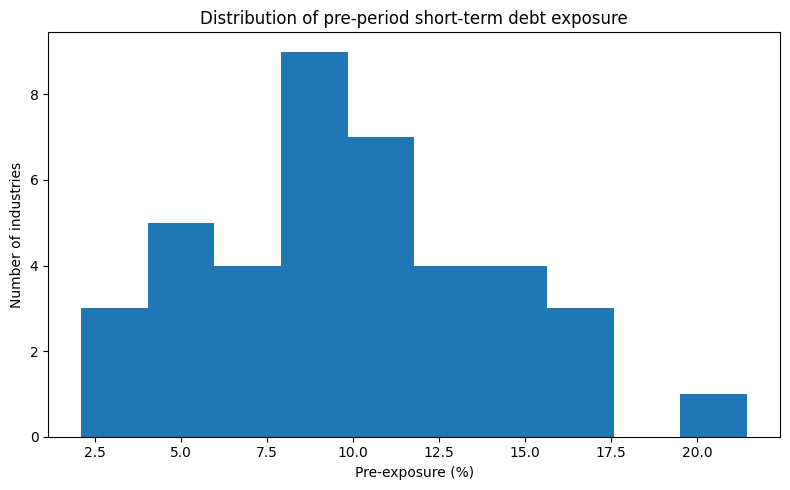

In [11]:

# 그래프 1: pre-exposure 분포
plt.figure(figsize=(8, 5))
plt.hist(pre_values, bins=10)
plt.xlabel("Pre-exposure (%)")
plt.ylabel("Number of industries")
plt.title("Distribution of pre-period short-term debt exposure")
plt.tight_layout()
plt.show()


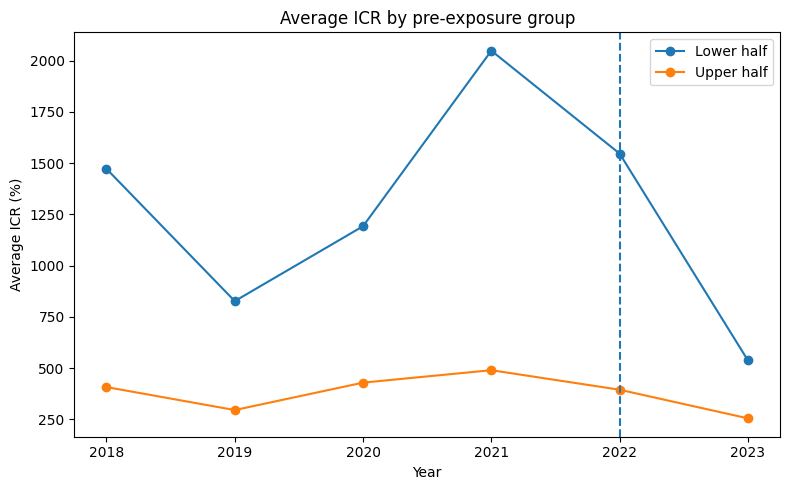

시각화용 노출도 중앙값: 9.66050527517083


In [12]:

# 그래프 2: 노출도 상/하위 절반의 연도별 평균 ICR
median_exposure = statistics.median(pre_values)

annual_low = []
annual_high = []

for year in ANALYSIS_YEARS:
    low_values = [
        row["icr"]
        for row in panel
        if row["year"] == year
        and row["pre_exposure_pct"] <= median_exposure
        and row["icr"] is not None
    ]

    high_values = [
        row["icr"]
        for row in panel
        if row["year"] == year
        and row["pre_exposure_pct"] > median_exposure
        and row["icr"] is not None
    ]

    annual_low.append(statistics.mean(low_values))
    annual_high.append(statistics.mean(high_values))

plt.figure(figsize=(8, 5))
plt.plot(ANALYSIS_YEARS, annual_low, marker="o", label="Lower half")
plt.plot(ANALYSIS_YEARS, annual_high, marker="o", label="Upper half")
plt.axvline(2022, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Average ICR (%)")
plt.title("Average ICR by pre-exposure group")
plt.legend()
plt.tight_layout()
plt.show()

print("시각화용 노출도 중앙값:", median_exposure)



## 11. ICR 극단값 민감도 분석

기본모형은 원자료를 그대로 사용했습니다.

ICR은 분모인 이자비용이 매우 작거나 영업이익이 큰 경우 극단적으로 커질 수 있으므로,  
결과가 몇 개의 큰 값에 의해 좌우되는지 보기 위해 **추가 진단**을 합니다.

여기서는 분석자가 정한 탐색적 규칙으로 ICR을 전체 2018~2023 분포의 **1%와 99% 분위수에서 winsorize**합니다.

중요:

- 이것은 본 결과를 대체하지 않습니다.
- 유의성을 만들기 위한 조정이 아닙니다.
- 기본모형과 방향·크기가 크게 달라지는지만 확인합니다.


In [13]:

icr_p01 = quantile(icr_values, 0.01)
icr_p99 = quantile(icr_values, 0.99)

Y_winsor = np.array(
    [
        min(max(row["icr"], icr_p01), icr_p99)
        for row in reg_panel
    ],
    dtype=float,
)

model_winsor = sm.OLS(Y_winsor, X).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": cluster_groups,
        "use_correction": True,
        "df_correction": True,
    },
    use_t=True,
)

beta_w = model_winsor.params[beta_index]
se_w = model_winsor.bse[beta_index]
t_w = model_winsor.tvalues[beta_index]
p_w = model_winsor.pvalues[beta_index]
ci_w_low, ci_w_high = model_winsor.conf_int()[beta_index]

print("===== 1% / 99% winsorized 민감도 분석 =====")
print(f"winsor 하한 = {icr_p01:.4f}")
print(f"winsor 상한 = {icr_p99:.4f}")
print(f"β           = {beta_w:.4f}")
print(f"Cluster SE  = {se_w:.4f}")
print(f"t           = {t_w:.4f}")
print(f"p           = {p_w:.4f}")
print(f"95% CI      = [{ci_w_low:.4f}, {ci_w_high:.4f}]")
print(f"R²          = {model_winsor.rsquared:.4f}")


===== 1% / 99% winsorized 민감도 분석 =====
winsor 하한 = -722.2630
winsor 상한 = 8287.6280
β           = 61.2366
Cluster SE  = 36.9930
t           = 1.6554
p           = 0.1059
95% CI      = [-13.5889, 136.0620]
R²          = 0.7636



## 12. 결과 엑셀 저장

노트북을 실행한 뒤 주요 산출물을 `ISTANS_7단계_예비추정_결과.xlsx`로 저장합니다.

시트 구성:

- `요약`
- `패널_2018_2023`
- `사전노출도`
- `회귀결과`
- `민감도`
- `연도별_ICR`

이 파일은 분석 결과 확인용이며, 원본 ISTANS 파일을 수정하지 않습니다.


In [14]:

# ------------------------------------------------------------
# 결과표에 들어갈 데이터 준비
# ------------------------------------------------------------

# 업종별 사전노출도
exposure_table = []

for code in industry_codes:
    exposure_table.append([
        code,
        industry_names[code],
        exposure_by_industry_year[(code, 2018)] * 100,
        exposure_by_industry_year[(code, 2019)] * 100,
        exposure_by_industry_year[(code, 2020)] * 100,
        pre_exposure[code] * 100,
    ])


# 연도별 ICR 평균
annual_icr_table = []

for year in ANALYSIS_YEARS:
    values = [
        row["icr"]
        for row in panel
        if row["year"] == year and row["icr"] is not None
    ]

    low_values = [
        row["icr"]
        for row in panel
        if row["year"] == year
        and row["pre_exposure_pct"] <= median_exposure
        and row["icr"] is not None
    ]

    high_values = [
        row["icr"]
        for row in panel
        if row["year"] == year
        and row["pre_exposure_pct"] > median_exposure
        and row["icr"] is not None
    ]

    annual_icr_table.append([
        year,
        statistics.mean(values),
        statistics.mean(low_values),
        statistics.mean(high_values),
    ])


if HAS_ARTIFACT:
    # ------------------------------------------------------------
    # workbook 생성
    # ------------------------------------------------------------
    result_wb = Workbook.create()

    # ===== 요약 =====
    ws = result_wb.worksheets.add("요약")

    ws.merge_cells("A1:C1")
    ws.get_range("A1").values = [["ISTANS 7단계 · 금리취약성 예비추정"]]
    ws.get_range("A1:C1").format = {
        "fill": "#1F4E78",
        "font": {"bold": True, "color": "#FFFFFF", "size": 14},
        "horizontal_alignment": "center",
    }

    summary_rows = [
        ["항목", "결과", "해석"],
        ["분석기간", "2018~2023", "40대 제조업 연간 패널"],
        ["관측치", n, "40업종 × 6년"],
        ["업종 수", len(codes_reg), ""],
        ["사전노출도 기간", "2018~2020", "(단기차입+단기사채)/자산총계 평균"],
        ["Post", "2022~2023 = 1", "예비적 구분이며 인과적 처치시점으로 단정하지 않음"],
        ["종속변수", "이자보상비율(ICR)", "단위 %"],
        ["기본 β", beta, "사전노출도 1%p 증가당 post 이후 상대적 ICR 차이"],
        ["기본 SE", se, "업종 cluster-robust"],
        ["기본 p-value", p_value, ""],
        ["기본 95% CI 하한", ci_low, ""],
        ["기본 95% CI 상한", ci_high, ""],
        ["민감도 β", beta_w, "ICR 1%/99% winsorized"],
        ["민감도 p-value", p_w, ""],
    ]

    ws.get_range(f"A3:C{2 + len(summary_rows)}").values = summary_rows
    ws.get_range("A3:C3").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }
    ws.get_range("A:C").format.wrap_text = True
    ws.get_range("A:A").format.column_width = 27
    ws.get_range("B:B").format.column_width = 20
    ws.get_range("C:C").format.column_width = 48


    # ===== 패널 =====
    ws = result_wb.worksheets.add("패널_2018_2023")

    panel_headers = [
        "업종코드", "업종", "연도",
        "자산총계", "단기차입", "단기사채",
        "차입의존도", "ICR",
        "사전노출도(%)", "Post", "Post×사전노출도"
    ]

    ws.get_range("A1:K1").values = [panel_headers]
    ws.get_range("A1:K1").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }

    panel_rows = [
        [
            row["code"],
            row["industry"],
            row["year"],
            row["assets"],
            row["short_borrowing"],
            row["short_bonds"],
            row["debt_dependence"],
            row["icr"],
            row["pre_exposure_pct"],
            row["post"],
            row["post_x_pre"],
        ]
        for row in panel
    ]

    ws.get_range(f"A2:K{1 + len(panel_rows)}").values = panel_rows
    ws.freeze_panes.freeze_rows(1)
    ws.get_range("A:K").format.autofit_columns()
    ws.get_range("B:B").format.column_width = 18


    # ===== 사전노출도 =====
    ws = result_wb.worksheets.add("사전노출도")

    ws.get_range("A1:F1").values = [[
        "업종코드", "업종",
        "2018 단기성부채/자산(%)",
        "2019 단기성부채/자산(%)",
        "2020 단기성부채/자산(%)",
        "2018~2020 평균(%)",
    ]]

    ws.get_range("A1:F1").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }

    ws.get_range(f"A2:F{1 + len(exposure_table)}").values = exposure_table
    ws.get_range("A:F").format.autofit_columns()
    ws.get_range("B:B").format.column_width = 18


    # ===== 회귀결과 =====
    ws = result_wb.worksheets.add("회귀결과")

    regression_rows = [
        ["변수", "계수", "표준오차", "t", "p-value", "95% CI 하한", "95% CI 상한"],
        ["Post × 사전노출도(%)", beta, se, t_value, p_value, ci_low, ci_high],
    ]

    ws.get_range("A1:G2").values = regression_rows
    ws.get_range("A1:G1").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }

    ws.get_range("A4:B9").values = [
        ["설정", "값"],
        ["N", n],
        ["업종 수", len(codes_reg)],
        ["산업 FE", "포함"],
        ["연도 FE", "포함"],
        ["업종 cluster SE", "사용"],
    ]

    ws.get_range("A4:B4").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }

    ws.get_range("A:G").format.autofit_columns()


    # ===== 민감도 =====
    ws = result_wb.worksheets.add("민감도")

    sensitivity_rows = [
        ["분석", "계수", "표준오차", "t", "p-value", "95% CI 하한", "95% CI 상한"],
        ["기본 원자료", beta, se, t_value, p_value, ci_low, ci_high],
        ["ICR 1%/99% winsorized", beta_w, se_w, t_w, p_w, ci_w_low, ci_w_high],
    ]

    ws.get_range("A1:G3").values = sensitivity_rows
    ws.get_range("A1:G1").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }
    ws.get_range("A:G").format.autofit_columns()


    # ===== 연도별 ICR =====
    ws = result_wb.worksheets.add("연도별_ICR")

    ws.get_range("A1:D1").values = [[
        "연도",
        "전체 평균 ICR",
        "노출도 하위 절반 평균",
        "노출도 상위 절반 평균",
    ]]

    ws.get_range("A1:D1").format = {
        "fill": "#D9EAF7",
        "font": {"bold": True},
    }

    ws.get_range(f"A2:D{1 + len(annual_icr_table)}").values = annual_icr_table
    ws.get_range("A:D").format.autofit_columns()


    # ------------------------------------------------------------
    # 저장
    # ------------------------------------------------------------
    RESULT_XLSX = INTERIM / "ISTANS_7단계_예비추정_결과.xlsx"
    SpreadsheetFile.export_xlsx(result_wb).save(str(RESULT_XLSX))

    print("결과 파일 저장 완료:", RESULT_XLSX.resolve())

else:
    print('artifact_tool 미설치: 엑셀 저장 단계를 건너뜀 (결과 파일은 레포에 포함)')

artifact_tool 미설치: 엑셀 저장 단계를 건너뜀 (결과 파일은 레포에 포함)



## 13. 최종 해석 및 한계

이 단계에서 답하려는 것은 매우 좁습니다.

> **현재 정의한 사전 단기성부채 노출도와 2022년 이후 ICR 사이에 어떤 상대적 패턴이 보이는가?**

### 이 분석으로 말할 수 있는 것
- 2018~2020의 단기성부채 비중이 높은 산업과 낮은 산업이 2022년 이후 ICR에서 어떻게 다르게 움직였는지
- 그 패턴의 방향과 불확실성
- 극단적인 ICR 값에 결과가 크게 의존하는지 여부

### 이 분석으로 말할 수 없는 것
- 기준금리 인상이 ICR을 인과적으로 변화시켰다는 결론
- 단기차입 비중이 실제 변동금리 노출과 동일하다는 주장
- `p < 0.05` 여부만으로 연구주제를 채택·폐기하는 판단
- 2022년에 발생한 다른 경기·원자재·수요 충격의 영향을 모두 제거했다는 주장

### 다음 연구단계에서 필요한 것
이 주제를 계속 발전시킨다면 단순한 `Post × 단기성부채비중`을 넘어서,
금리 노출 측정의 타당성, 산업별 경기충격, 결과변수 정의를 다시 검토해야 합니다.

따라서 이번 7단계는 **주제 판정용 예비 진단**으로만 사용합니다.
